# Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline 
import matplotlib.pyplot as plt
import plotly.express as px
import sklearn

In [2]:
cd C:\Users\Lenovo\OneDrive\Desktop

C:\Users\Lenovo\OneDrive\Desktop


In [30]:
filtered_data = pd.read_csv("311data.csv")
filtered_data.shape

(800000, 29)

In [31]:
filtered_data.isnull().sum()

_id                       0
group_id                  0
num_requests              0
parent_closed             0
status_name               0
status_code               0
dept                   4103
request_type_name         0
request_type_id           0
create_date_et            0
create_date_utc           0
last_action_et            0
last_action_utc           0
closed_date_et        89049
closed_date_utc       89049
origin                    0
street               308423
cross_street         698878
street_id            301948
cross_street_id      301948
city                      0
neighborhood          36109
census_tract         218417
council_district      34677
ward                  35943
police_zone           36202
latitude              30175
longitude             30175
geo_accuracy              0
dtype: int64

### Drop Columns that are redundant (not focus of the project)

In [32]:
cleaned_data = filtered_data.drop(columns=['create_date_utc', 'last_action_utc', 'closed_date_utc', 
                                           'cross_street','request_type_id'])
cleaned_data.shape

(800000, 24)

In [33]:
cleaned_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800000 entries, 0 to 799999
Data columns (total 24 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   _id                800000 non-null  int64  
 1   group_id           800000 non-null  int64  
 2   num_requests       800000 non-null  int64  
 3   parent_closed      800000 non-null  object 
 4   status_name        800000 non-null  object 
 5   status_code        800000 non-null  int64  
 6   dept               795897 non-null  object 
 7   request_type_name  800000 non-null  object 
 8   create_date_et     800000 non-null  object 
 9   last_action_et     800000 non-null  object 
 10  closed_date_et     710951 non-null  object 
 11  origin             800000 non-null  object 
 12  street             491577 non-null  object 
 13  street_id          498052 non-null  float64
 14  cross_street_id    498052 non-null  float64
 15  city               800000 non-null  object 
 16  ne

In [34]:
cleaned_data.isnull().sum()

_id                       0
group_id                  0
num_requests              0
parent_closed             0
status_name               0
status_code               0
dept                   4103
request_type_name         0
create_date_et            0
last_action_et            0
closed_date_et        89049
origin                    0
street               308423
street_id            301948
cross_street_id      301948
city                      0
neighborhood          36109
census_tract         218417
council_district      34677
ward                  35943
police_zone           36202
latitude              30175
longitude             30175
geo_accuracy              0
dtype: int64

### Converting to datetime format

In [35]:
# Convert date columns to DateTime format
cleaned_data['create_date_et'] = pd.to_datetime(cleaned_data['create_date_et'], errors='coerce')
cleaned_data['closed_date_et'] = pd.to_datetime(cleaned_data['closed_date_et'], errors='coerce')

### Filling in missing values 
#### neighborhood

In [36]:
# Fill in missing neighborhoods using latitude and longitude
missing_values_count = cleaned_data['neighborhood'].isna().sum()
print(f" Initial Missing values in neighborhood: {missing_values_count}")

# Reverse geocoding function
def get_neighborhood(lat, lon):
    try:
        location = geolocator.reverse(f"{lat}, {lon}", exactly_one=True)
        return location.raw['address'].get('neighbourhood', 'Unknown')
    except:
        return 'Unknown'

#Execute only on data that lacks neighborhood and has longitude and latitude
mask = cleaned_data['neighborhood'].isna() & cleaned_data['latitude'].notna() & cleaned_data['longitude'].notna()
cleaned_data.loc[mask, 'neighborhood'] = cleaned_data[mask].apply(
    lambda row: get_neighborhood(row['latitude'], row['longitude']), axis=1
)

missing_values_count = cleaned_data['neighborhood'].isna().sum()
print(f"Missing values in neighborhood: {missing_values_count}")

 Initial Missing values in neighborhood: 36109
Missing values in neighborhood: 30155


In [37]:
# Checking proportion of neighborhoods missing 
missing_neighborhoods = cleaned_data[cleaned_data['neighborhood'] == 'Unknown']
missing_neighborhoods_count = len(missing_neighborhoods)
total_count = len(cleaned_data)
missing_neighborhoods_proportion = missing_neighborhoods_count / total_count * 100
print(f"Proportion of neighborhoods missing: {missing_neighborhoods_proportion:.2f}%")

Proportion of neighborhoods missing: 0.74%


In [38]:
# Drop rows with missing values in 'neighborhood' and 'Unknown'
# Drop rows with missing values in 'neighborhood'
cleaned_data = cleaned_data[cleaned_data['neighborhood'] != 'Unknown']

# Drop rows with missing values in 'neighborhood'
cleaned_data = cleaned_data.dropna(subset=['neighborhood'])

missing_values_count = cleaned_data['neighborhood'].isna().sum()
print(f"Missing values in neighborhood: {missing_values_count}")

Missing values in neighborhood: 0


#### police_zone

In [39]:
# Fill in missing value for police_zone
# Fill values based on https://pghsafeneighborhoods.wordpress.com/wp-content/uploads/2008/06/zones-by-neighborhood.pdf

# Neighborhoods without police zone
unique_neighborhoods = cleaned_data.loc[cleaned_data['police_zone'].isna(), 'neighborhood'].unique()
print(unique_neighborhoods)

# Fill in missing values for police_zone
dict_neighborhoods_policezone = {'Windgap': 6.0, 
                                 'Overbrook': 3.0,
                                 'Mount Oliver Borough': 3.9,
                                 'Mt. Oliver': 3.0,
                                 'Swisshelm Park': 4.0,
                                 'Westwood': 6.0,
                                 'Banksville': 3.0,
                                 'Fairywood': 6.0,
                                 'Knoxville': 3.0,
                                 'Ridgemont': 3.0,
                                 'East Carnegie': 6.0,
                                 'Oakwood': 6.0
}

for neighborhood, police_zone in dict_neighborhoods_policezone.items():
    cleaned_data.loc[cleaned_data['neighborhood'] == neighborhood, 'police_zone'] = police_zone

# Check if there are still missing values
missing_values_count = cleaned_data['police_zone'].isna().sum()
print(f"Missing values in police_zone: {missing_values_count}")

['Mount Oliver Borough' 'Windgap' 'Overbrook' 'Mt. Oliver'
 'Swisshelm Park' 'Oakwood' 'Westwood' 'Brookline' 'Ridgemont' 'Fairywood'
 'Banksville' 'Carrick' 'Knoxville' 'East Carnegie']
Missing values in police_zone: 2


In [40]:
# Drop rows with missing values in 'police_zone'
cleaned_data = cleaned_data.dropna(subset=['police_zone'])
cleaned_data = cleaned_data[cleaned_data['police_zone'] != 0]


In [41]:
# Check if there are still missing values
missing_values_count = cleaned_data['police_zone'].isna().sum() + (cleaned_data['police_zone'] == 0).sum()
print(f"Missing values in police_zone: {missing_values_count}")

Missing values in police_zone: 0


#### council

In [42]:
# Fill in Council District
cleaned_data['council_district'].unique()

mapping = {
    "Knoxville": 3,
    "Regent Square": 5,
    "Carrick": 4,
    "Fairywood": 2,
    "Oakwood": 2,
    "Lincoln Place": 5,
    "Brookline": 4,
    "East Hills": 9,
    "Westwood": 2,
    "Point Breeze": 8,
    "Homewood South": 9,
    "Overbrook": 4,
    "Spring Garden": 1,
    "Beechview": 4,
    "Perry North": 1,
    "Point Breeze North": 8,
    "Squirrel Hill North": 8,
    "Arlington": 3,
    "East Carnegie": 2,
    "East Liberty": 9,
    "North Oakland": 8,
    "Strip District": 7,
    "Summer Hill": 1,
    "Mount Oliver Borough": 11,}

missing_mask = cleaned_data['council_district'].isna()

cleaned_data.loc[missing_mask, 'council_district'] = cleaned_data.loc[missing_mask, 'neighborhood'].map(mapping)

missing_values_count = cleaned_data['council_district'].isna().sum()
print(f"Missing values in council_district: {missing_values_count}")


Missing values in council_district: 0


#### department

In [43]:
# Fill in missing departments using codebook (from 311Codebook.csv)

codebook = pd.read_csv("311 Codebook Request Types - Codebook.csv")

# Create a mapping dictionary for Issue and Department
issue_dept_mapping = codebook.set_index('Issue')['Department'].to_dict()

# Fill missing departments in cleaned_data using the mapping
cleaned_data['dept'] = cleaned_data.apply(
    lambda row: issue_dept_mapping[row['request_type_name']] if pd.isna(row['dept']) and row['request_type_name'] in issue_dept_mapping else row['dept'],
    axis=1
)

# Remaining missing rows fall under the category 'In database, but not on 311 Web Submission Form'

In [44]:
# Check neighborhoods with missing departments as a proportion of the total requests in the neighborhood
neighborhood_counts = cleaned_data['neighborhood'].value_counts()
neighborhood_counts = neighborhood_counts[neighborhood_counts > 0]

# Calculate the proportion of missing departments for each neighborhood
proportion_missing_dept = cleaned_data[cleaned_data['dept'].isna()]['neighborhood'].value_counts() / neighborhood_counts
proportion_missing_dept = proportion_missing_dept[proportion_missing_dept > 0]

# Sort the neighborhoods by proportion of missing departments
proportion_missing_dept = proportion_missing_dept.sort_values(ascending=False)

proportion_missing_dept

neighborhood
Crawford-Roberts     0.028875
Middle Hill          0.024030
Crafton Heights      0.019164
North Oakland        0.017091
East Carnegie        0.016575
                       ...   
Oakwood              0.001294
Ridgemont            0.001116
Chartiers City       0.000899
South Side Slopes    0.000694
Bon Air              0.000439
Name: count, Length: 88, dtype: float64

In [45]:
# Since the missing departments are not significant, we can drop the rows with missing departments
cleaned_data = cleaned_data.dropna(subset=['dept'])

In [46]:
cleaned_data.isnull().sum()

_id                       0
group_id                  0
num_requests              0
parent_closed             0
status_name               0
status_code               0
dept                      0
request_type_name         0
create_date_et            0
last_action_et            0
closed_date_et        83262
origin                    0
street               273654
street_id            270733
cross_street_id      270733
city                      0
neighborhood              0
census_tract         182140
council_district          0
ward                     54
police_zone               0
latitude                 19
longitude                19
geo_accuracy              0
dtype: int64

### Create Columns
#### dept → category

In [47]:
# Create a new column called Category for request types using the codebook

# Create a mapping dictionary for Issue and Category
issue_category_mapping = codebook.set_index('Issue')['Category'].to_dict()

# Create new columns called category and input values based on the mapping
cleaned_data['category'] = cleaned_data.apply(
    lambda row: issue_category_mapping[row['request_type_name']] if row['request_type_name'] in issue_category_mapping else row['request_type_name'],
    axis=1
)

# Check if there are still missing values
missing_values_count = cleaned_data['category'].isna().sum()
missing_values_count

0

In [48]:
# Simplify the Department names
cleaned_data['dept_simplified'] = cleaned_data['dept'].str.split(' - ').str[0]
cleaned_data['dept_simplified'].unique()

dept_counts = cleaned_data['dept_simplified'].value_counts()
dept_counts

dept_simplified
DPW                                     309146
Permits, Licenses and Inspections       164443
DOMI                                    102289
Police                                   78112
Pittsburgh Water and Sewer Authority     29493
Animal Care & Control                    22611
Finance                                  12227
Allegheny City Electric                  11115
Sargent Electric                          6532
311                                       5835
Fire Bureau                               2487
Parking Authority                         2395
Public Safety                             2239
City Planning                             1660
OMI                                       1640
ACHD                                      1521
SPIN Scooters                             1246
Mayor's Office                             852
911                                        815
Commission on Human Relations              539
Port Authority Transit                     5

### Dropping rows/columns

In [49]:
cleaned_data.isnull().sum()

_id                       0
group_id                  0
num_requests              0
parent_closed             0
status_name               0
status_code               0
dept                      0
request_type_name         0
create_date_et            0
last_action_et            0
closed_date_et        83262
origin                    0
street               273654
street_id            270733
cross_street_id      270733
city                      0
neighborhood              0
census_tract         182140
council_district          0
ward                     54
police_zone               0
latitude                 19
longitude                19
geo_accuracy              0
category                  0
dept_simplified           0
dtype: int64

In [50]:
cleaned_data = cleaned_data.dropna(subset=['longitude'])

In [51]:
cleaned_data = cleaned_data.dropna(subset=['latitude'])

3# Dropping rows with missing census_tract values since it is hard to impute and there are too many missing
cleaned_data = cleaned_data.drop(columns=['census_tract', 'latitude', 'longitude'])

In [52]:
# Dropping rows with missing wards because they are not directly related to neighborhoods

# Show the proportion of missing wards in the dataset (NaNs and 0s represent missing wards)
missing_wards_count = cleaned_data['ward'].isna().sum() + (cleaned_data['ward'] == 0).sum()
total_count = len(cleaned_data)
missing_wards_proportion = missing_wards_count / total_count * 100
print(f"Proportion of missing wards: {missing_wards_proportion:.2f}%")

# Drop rows with missing values in 'ward'
cleaned_data = cleaned_data.dropna(subset=['ward'])
cleaned_data = cleaned_data[cleaned_data['ward'] != 0]

# Check if there are still missing values
missing_values_count = cleaned_data['ward'].isna().sum() + (cleaned_data['ward'] == 0).sum()
print(f"Missing values in ward: {missing_values_count}")

Proportion of missing wards: 0.03%
Missing values in ward: 0


In [53]:
# Removing rows with '(DO NOT USE)' in request_type_name
cleaned_data = cleaned_data[~cleaned_data['request_type_name'].str.contains(r'\(DO NOT USE\)', case=False, na=False)]

In [54]:
# Dropping request_type_name and using Category instead
cleaned_data = cleaned_data.drop(columns=['request_type_name'])

# Dropping dept and using dept_simplified instead
cleaned_data = cleaned_data.drop(columns=['dept'])

In [55]:
cleaned_data.isnull().sum()

_id                      0
group_id                 0
num_requests             0
parent_closed            0
status_name              0
status_code              0
create_date_et           0
last_action_et           0
closed_date_et       83196
origin                   0
street              273517
street_id           270602
cross_street_id     270602
city                     0
neighborhood             0
census_tract        181761
council_district         0
ward                     0
police_zone              0
latitude                 0
longitude                0
geo_accuracy             0
category                 0
dept_simplified          0
dtype: int64

In [56]:
cleaned_data.shape

(759654, 24)

### Adding Demographic Data

In [57]:
# Read in neighborhood data
neighborhoods = pd.read_csv('2020Census_Neighborhood_Dataset.csv')

In [58]:
# Removing columns from 2010 and that are comparisons between 2020 and 2010
to_drop = neighborhoods.columns[neighborhoods.columns.str.startswith(('2010', 'Change'))]
neighborhoods.drop(to_drop, axis=1, inplace=True)

In [59]:
# Changing Neighborhood column capitalization to make merging easier
neighborhoods = neighborhoods.rename(columns = {'Neighborhood': 'neighborhood'})

# Dropping _id column
neighborhoods.drop('_id', axis=1, inplace=True)

In [60]:
neighborhoods

,neighborhood,2020_Total_Population,2020_OneRace_Population,2020_White_Alone_Population,2020_Black_Alone_Population,2020_American_Indian_and_Alaska_Native_alone_population,2020_Asian_Alone_Population,2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio,2020_Any_other_single_race_alone_Popualtion,2020_Population_two_or_more_races,2020_Hispanic_or_Latino_Population
0,Allegheny Center,1419,1337,683,390,8,235,1,20,82,50
1,Allegheny West,540,493,426,32,1,16,1,17,47,41
2,Allentown,2305,2126,1272,785,3,19,6,41,179,81
3,Arlington - Arlington Heights (Combined),2040,1889,1206,620,5,12,0,46,151,68
4,Banksville,4127,3856,3191,194,7,385,2,77,271,158
...,...,...,...,...,...,...,...,...,...,...,...
84,Upper Lawrenceville,2394,2266,2018,154,5,74,0,15,128,66
85,West End,205,180,118,50,1,6,2,3,25,11
86,West Oakland,2534,2455,1532,608,6,197,2,110,79,112
87,Westwood,3332,3147,2196,278,3,592,2,76,185,122


In [61]:
# Changing each neighborhood's race columns to proportions of the neighborhood's population

# Applying to all columns except 'neighborhood' and '2020_Total_Population'
neighborhoods.iloc[:, 2:].astype('float64')
neighborhoods.iloc[:, 2:] = neighborhoods.iloc[:, 2:].div(neighborhoods['2020_Total_Population'], axis=0);

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24908\240816995.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     0.942213
1     0.912963
2     0.922343
3     0.925980
4     0.934335
        ...   
84    0.946533
85    0.878049
86    0.968824
87    0.944478
88    0.936012
Name: 2020_OneRace_Population, Length: 89, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  neighborhoods.iloc[:, 2:] = neighborhoods.iloc[:, 2:].div(neighborhoods['2020_Total_Population'], axis=0);
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24908\240816995.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0     0.481325
1     0.788889
2     0.551844
3     0.591176
4     0.773201
        ...   
84    0.842941
85    0.575610
86    0.604578
87    0.659064
88    0.530506
Name: 2020_White_Alone_Population, Length: 89

In [62]:
# Changes in dataset -> census data

# Central Business District -> Central Business District (Downtown)
# Spring Hill-City View -> 	Spring Hill-City
# Mount Oliver Borough -> Mt. Oliver
# Arlington -> Arlington - Arlington Heights (Combined)
# Arlington Heights -> 	Arlington - Arlington Heights (Combined)

recode_nbhds = {'Central Business District': 'Central Business District (Downtown)', 'Spring Hill-City View': 'Spring Hill-City',
                'Mount Oliver Borough': 'Mt. Oliver', 'Arlington': 'Arlington - Arlington Heights (Combined)',
                'Arlington Heights': 'Arlington - Arlington Heights (Combined)'}

# Making changes to original DataFrame to combine neighborhood data
cleaned_data['neighborhood'] = cleaned_data['neighborhood'].replace(recode_nbhds)

In [63]:
# Merging both DataFrames on neighborhood columns
cleaned_data = pd.merge(cleaned_data, neighborhoods, how = 'left', on = 'neighborhood')

In [64]:
cleaned_data.columns

Index(['_id', 'group_id', 'num_requests', 'parent_closed', 'status_name',
       'status_code', 'create_date_et', 'last_action_et', 'closed_date_et',
       'origin', 'street', 'street_id', 'cross_street_id', 'city',
       'neighborhood', 'census_tract', 'council_district', 'ward',
       'police_zone', 'latitude', 'longitude', 'geo_accuracy', 'category',
       'dept_simplified', '2020_Total_Population', '2020_OneRace_Population',
       '2020_White_Alone_Population', '2020_Black_Alone_Population',
       '2020_American_Indian_and_Alaska_Native_alone_population',
       '2020_Asian_Alone_Population',
       '2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio',
       '2020_Any_other_single_race_alone_Popualtion',
       '2020_Population_two_or_more_races',
       '2020_Hispanic_or_Latino_Population'],
      dtype='object')

In [65]:
cleaned_data['parent_closed'] = cleaned_data['parent_closed'].replace({'t': 1, 'f': 0})

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24908\2794220475.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned_data['parent_closed'] = cleaned_data['parent_closed'].replace({'t': 1, 'f': 0})


In [66]:
cleaned_data = cleaned_data.drop(columns=['_id','group_id'])

In [67]:
cleaned_data.nunique(axis=0)

num_requests                                                           40
parent_closed                                                           2
status_name                                                             4
status_code                                                             4
create_date_et                                                     603103
last_action_et                                                     440931
closed_date_et                                                     393133
origin                                                                 10
street                                                               6199
street_id                                                            6228
cross_street_id                                                      5642
city                                                                   24
neighborhood                                                           89
census_tract                          

In [68]:
cleaned_data = cleaned_data.drop(columns=['status_name','parent_closed','status_code'])

In [70]:
data_recent =cleaned_data.sort_values('create_date_et')

In [71]:
data_recent['create_date_et']

128651   2015-04-20 07:37:00
171952   2015-04-20 07:40:00
90446    2015-04-20 07:41:00
385404   2015-04-20 07:46:00
385633   2015-04-20 07:47:00
                 ...        
759651   2024-12-18 09:28:00
759648   2024-12-18 09:32:00
759647   2024-12-18 09:39:00
759644   2024-12-18 09:40:00
759653   2024-12-18 09:41:00
Name: create_date_et, Length: 759654, dtype: datetime64[ns]

In [72]:
recent_mask = data_recent['create_date_et'].dt.year >= 2021
X_recent = data_recent.loc[recent_mask, :]

In [73]:
X_recent['create_date_et']

406945   2021-01-01 03:26:00
265555   2021-01-01 06:17:00
326559   2021-01-01 06:20:00
237711   2021-01-01 10:34:00
414644   2021-01-01 10:47:00
                 ...        
759651   2024-12-18 09:28:00
759648   2024-12-18 09:32:00
759647   2024-12-18 09:39:00
759644   2024-12-18 09:40:00
759653   2024-12-18 09:41:00
Name: create_date_et, Length: 348812, dtype: datetime64[ns]

In [76]:
X_recent.shape

(348812, 29)

In [75]:
X_recent.isnull().sum()

num_requests                                                            0
create_date_et                                                          0
last_action_et                                                          0
closed_date_et                                                      48302
origin                                                                  0
street                                                             146124
street_id                                                          144727
cross_street_id                                                    144727
city                                                                    0
neighborhood                                                            0
census_tract                                                       121238
council_district                                                        0
ward                                                                    0
police_zone                           

In [77]:
X_recent[X_recent['street'].isna()]['create_date_et']

406945   2021-01-01 03:26:00
265555   2021-01-01 06:17:00
326559   2021-01-01 06:20:00
237711   2021-01-01 10:34:00
381795   2021-01-01 13:48:00
                 ...        
759649   2024-12-18 09:15:00
759652   2024-12-18 09:27:00
759651   2024-12-18 09:28:00
759644   2024-12-18 09:40:00
759653   2024-12-18 09:41:00
Name: create_date_et, Length: 146124, dtype: datetime64[ns]

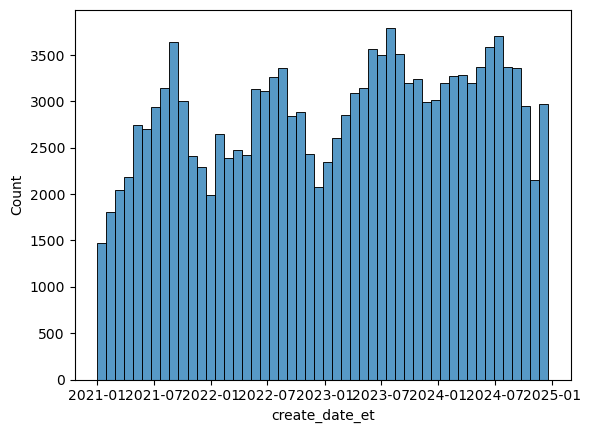

In [79]:
import seaborn as sns
sns.histplot(X_recent[X_recent['cross_street_id'].isna()]['create_date_et'],bins=50)
plt.show()

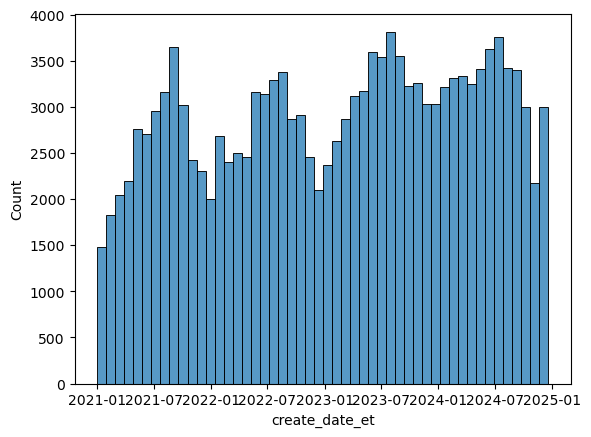

In [80]:
sns.histplot(X_recent[X_recent['street'].isna()]['create_date_et'],bins=50)
plt.show()

### Split the data to closed and non-closed

In [83]:
closed_requests =X_recent[X_recent['closed_date_et'].notna()].copy()
open_requests = X_recent[X_recent['closed_date_et'].isna()].copy()

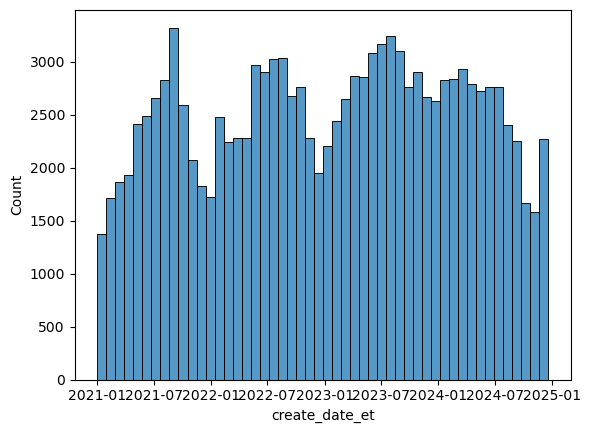

In [84]:
sns.histplot(closed_requests[closed_requests['street'].isna()]['create_date_et'],bins=50)
plt.show()

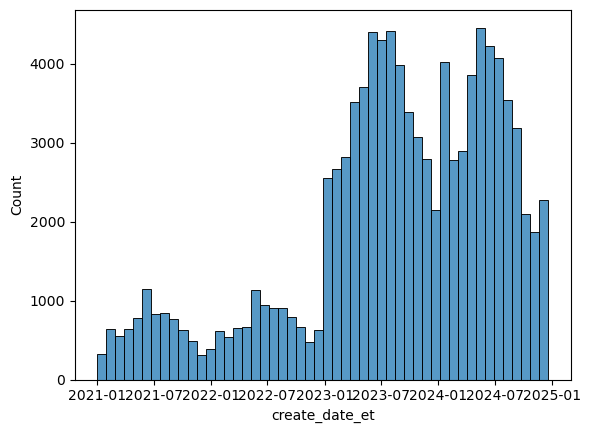

In [85]:
sns.histplot(closed_requests[closed_requests['census_tract'].isna()]['create_date_et'],bins=50)
plt.show()

In [86]:
closed_requests = closed_requests.drop(columns=['census_tract','street','cross_street_id','street_id'])

In [93]:
closed_requests.isnull().sum()

num_requests                                                       0
create_date_et                                                     0
last_action_et                                                     0
closed_date_et                                                     0
origin                                                             0
city                                                               0
neighborhood                                                       0
council_district                                                   0
ward                                                               0
police_zone                                                        0
latitude                                                           0
longitude                                                          0
geo_accuracy                                                       0
category                                                           0
dept_simplified                   

In [94]:
closed_requests.nunique(axis=0)

num_requests                                                           26
create_date_et                                                     241866
last_action_et                                                     159128
closed_date_et                                                     159128
origin                                                                  9
city                                                                   22
neighborhood                                                           89
council_district                                                        9
ward                                                                   32
police_zone                                                             6
latitude                                                           210879
longitude                                                          206316
geo_accuracy                                                            2
category                              

In [96]:
closed_requests['last_action_et'] = pd.to_datetime(closed_requests['last_action_et'], errors='coerce')

In [97]:
closed_requests.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300510 entries, 406945 to 759653
Data columns (total 25 columns):
 #   Column                                                           Non-Null Count   Dtype         
---  ------                                                           --------------   -----         
 0   num_requests                                                     300510 non-null  int64         
 1   create_date_et                                                   300510 non-null  datetime64[ns]
 2   last_action_et                                                   300510 non-null  datetime64[ns]
 3   closed_date_et                                                   300510 non-null  datetime64[ns]
 4   origin                                                           300510 non-null  object        
 5   city                                                             300510 non-null  object        
 6   neighborhood                                                     300

In [98]:
cleaned_data_encoded = pd.get_dummies(closed_requests, sparse=True)

In [99]:
cleaned_data_encoded.shape

(300510, 301)

In [107]:
cleaned_data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300510 entries, 406945 to 759653
Columns: 301 entries, num_requests to dept_simplified_School Guards
dtypes: Sparse[bool, False](282), datetime64[ns](3), float64(14), int64(2)
memory usage: 54.5 MB


#### Creat Y (time_taken)

In [108]:
cleaned_data_encoded['time_taken'] = (cleaned_data_encoded['closed_date_et'] - cleaned_data_encoded['create_date_et']).dt.total_seconds()
cleaned_data_encoded['time_taken']

406945      378720.0
265555      461940.0
326559    19105080.0
237711      253680.0
414644      332520.0
             ...    
759649      179940.0
759651         900.0
759648       64740.0
759647      191400.0
759653     7254180.0
Name: time_taken, Length: 300510, dtype: float64

### Create more features

In [109]:
# 基础时间特征
cleaned_data_encoded['create_hour'] = cleaned_data_encoded['create_date_et'].dt.hour
cleaned_data_encoded['create_month'] = cleaned_data_encoded['create_date_et'].dt.month

In [110]:
import holidays
us_holidays = holidays.US(years=cleaned_data_encoded['create_date_et'].dt.year.unique())
cleaned_data_encoded['is_holiday'] = cleaned_data_encoded['create_date_et'].apply(lambda x: x in us_holidays).astype(int)

In [111]:
cleaned_data_encoded['head_time_taken'] = (cleaned_data_encoded['last_action_et'] - cleaned_data_encoded['create_date_et']).dt.total_seconds()
cleaned_data_encoded['tail_time_taken'] = (cleaned_data_encoded['closed_date_et'] - cleaned_data_encoded['last_action_et']).dt.total_seconds()

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(121)
for i in ['num_requests', 'council_district', 'ward', 'police_zone', 'latitude', 'longitude', '2020_Total_Population', '2020_OneRace_Population', '2020_White_Alone_Population', '2020_Black_Alone_Population', '2020_American_Indian_and_Alaska_Native_alone_population', '2020_Asian_Alone_Population', '2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio', '2020_Any_other_single_race_alone_Popualtion', '2020_Population_two_or_more_races', '2020_Hispanic_or_Latino_Population', 'create_hour', 'create_month']:
    sns.histplot(closed_requests[i], bins=50)
    plt.show()

In [115]:
num_cols = cleaned_data_encoded.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('time_taken') 
num_cols.remove('head_time_taken')
num_cols.remove('tail_time_taken')

cols_to_standardize = []
for col in num_cols:
    unique_vals = cleaned_data_encoded[col].dropna().unique()
    if not (set(unique_vals) <= {0,1}):
        cols_to_standardize.append(col)

print("need to standardize：", cols_to_standardize)

need to standardize： ['num_requests', 'council_district', 'ward', 'police_zone', 'latitude', 'longitude', '2020_Total_Population', '2020_OneRace_Population', '2020_White_Alone_Population', '2020_Black_Alone_Population', '2020_American_Indian_and_Alaska_Native_alone_population', '2020_Asian_Alone_Population', '2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio', '2020_Any_other_single_race_alone_Popualtion', '2020_Population_two_or_more_races', '2020_Hispanic_or_Latino_Population', 'create_hour', 'create_month']


#### Standardized and check the distribution of features

In [116]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cleaned_data_encoded['time_taken'] = scaler.fit_transform(cleaned_data_encoded[['time_taken']])

In [117]:
cleaned_data_encoded.shape

(300510, 307)

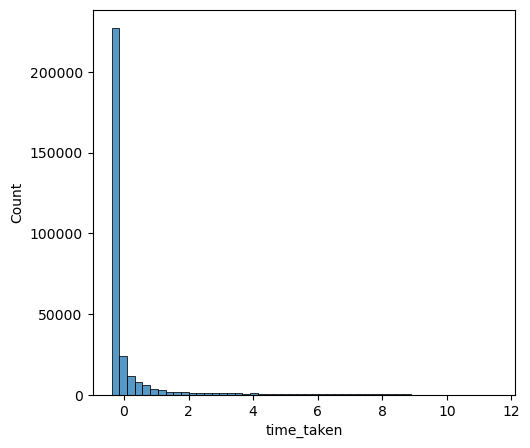

In [120]:
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(cleaned_data_encoded['time_taken'], bins=50)
plt.show()

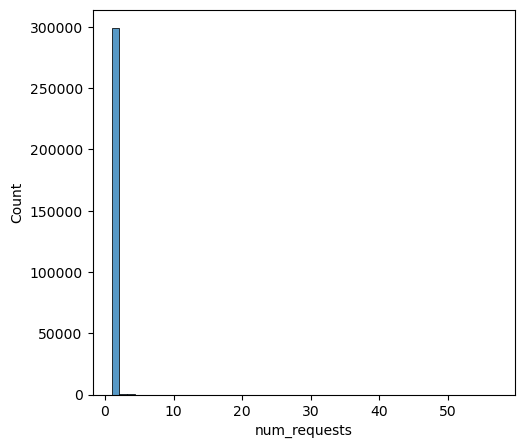

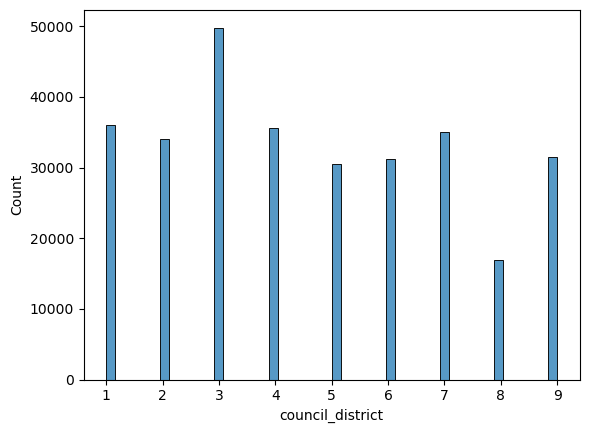

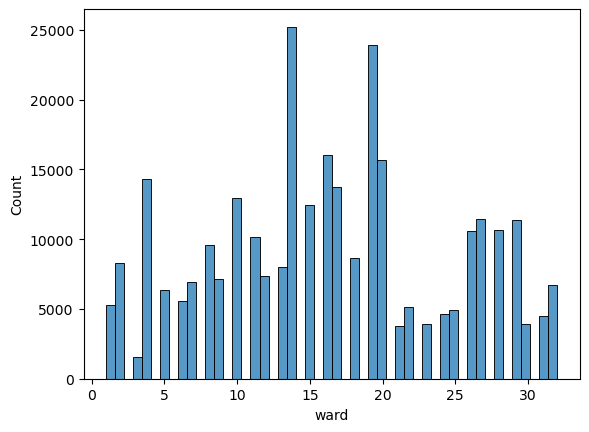

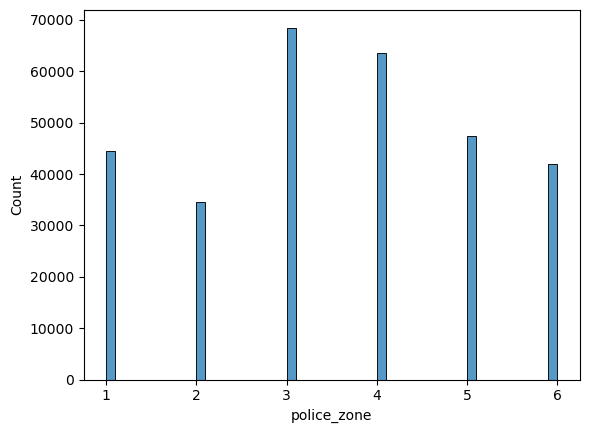

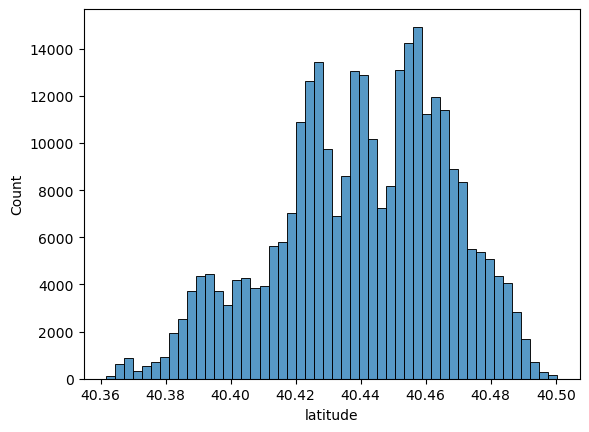

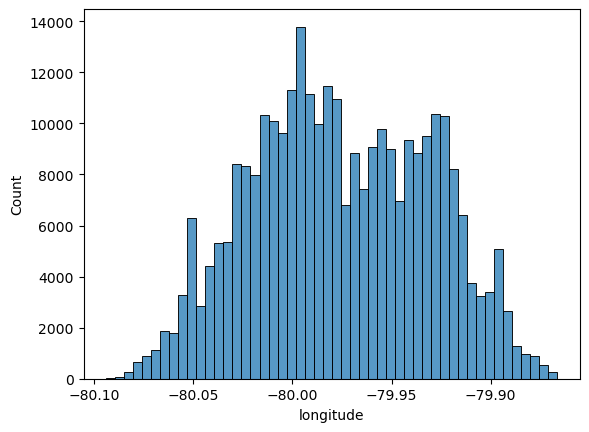

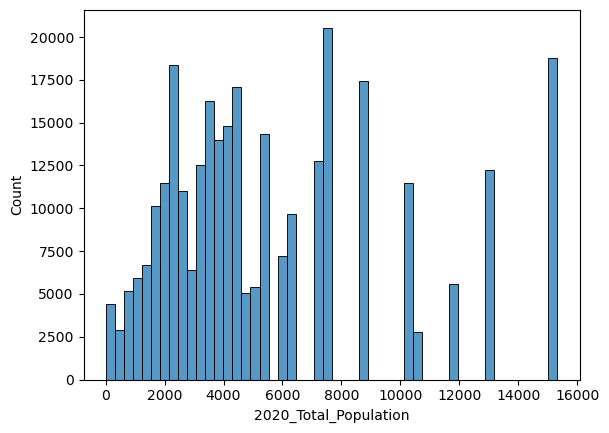

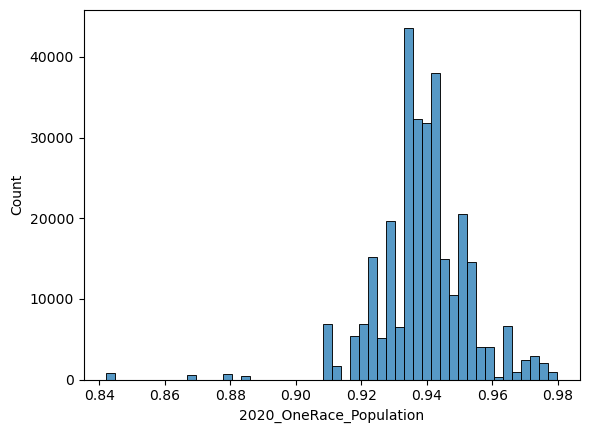

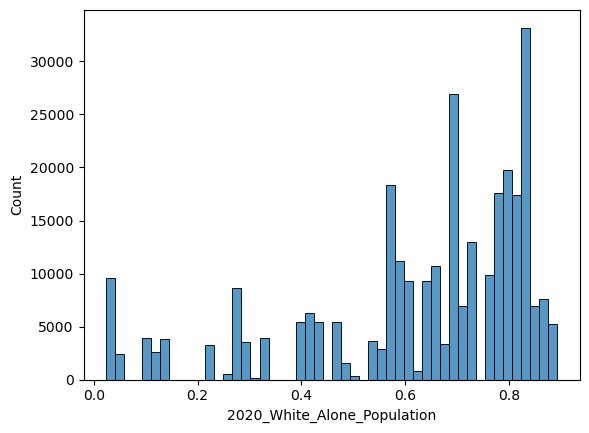

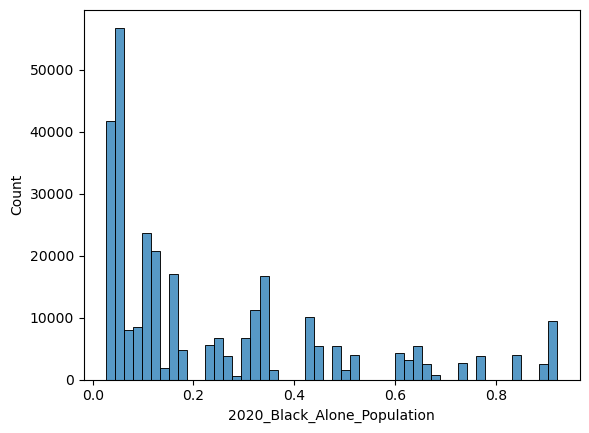

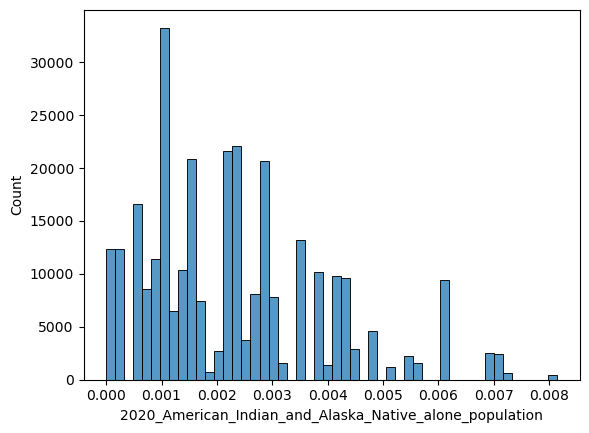

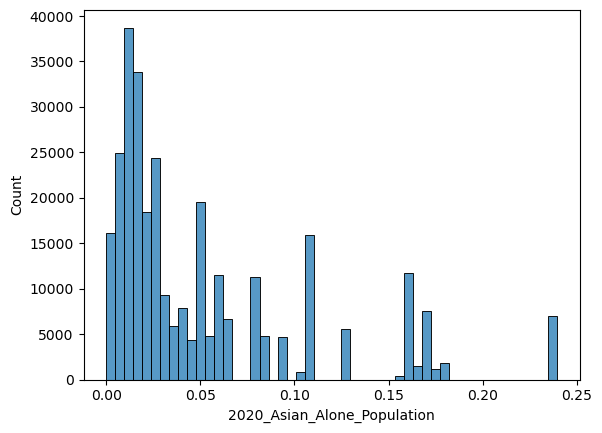

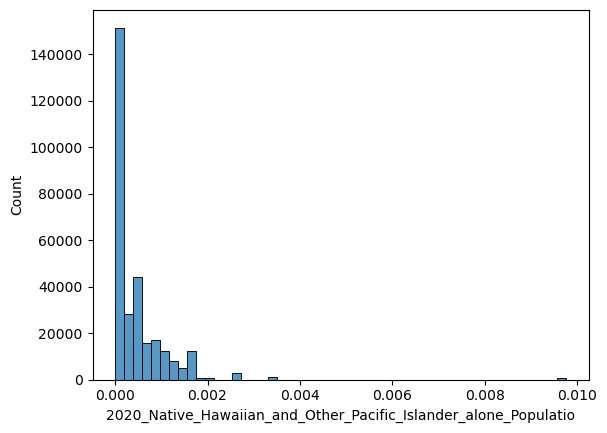

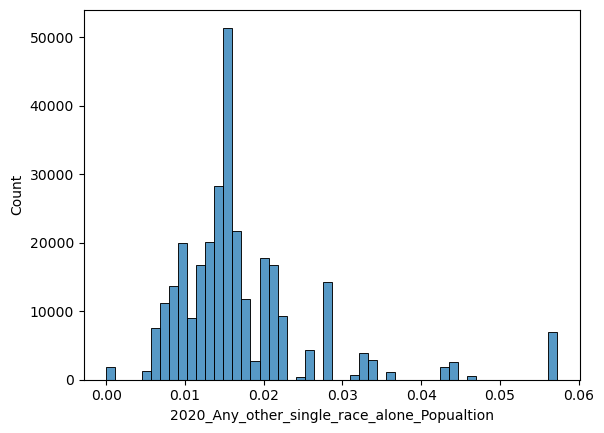

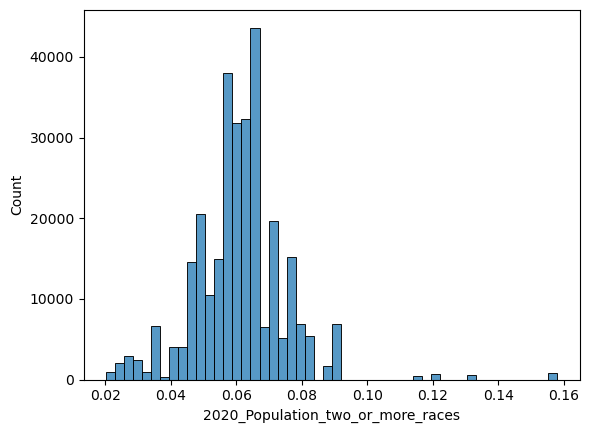

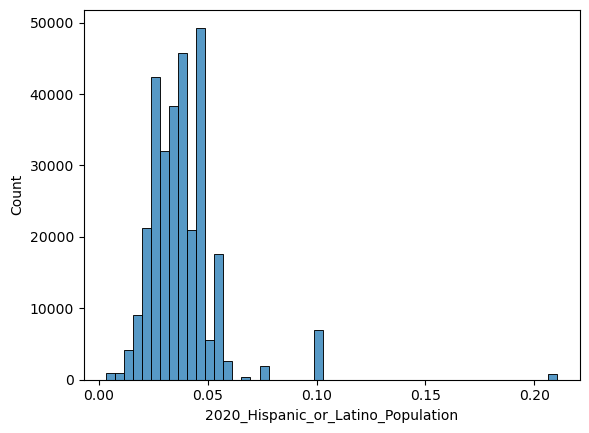

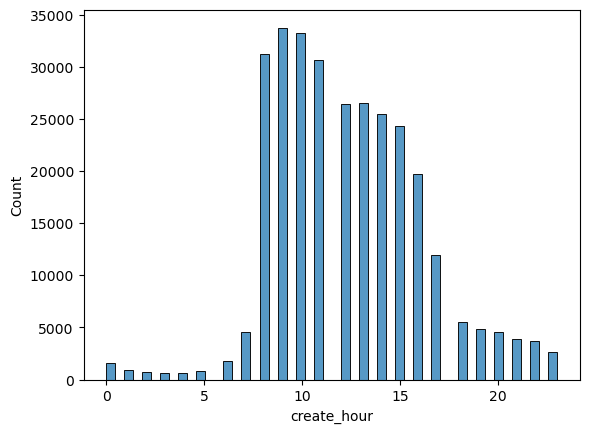

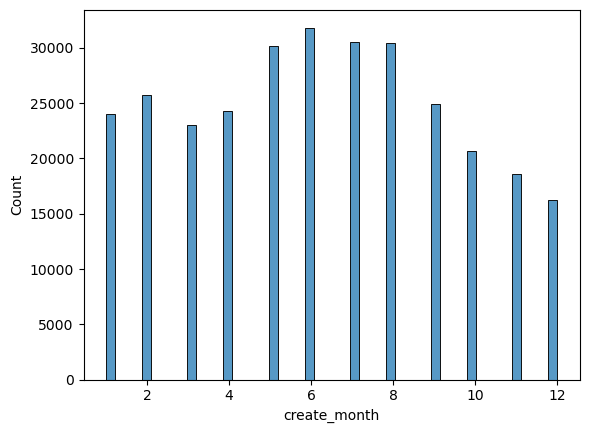

In [119]:
plt.figure(figsize=(12,5))
plt.subplot(121)
for i in cols_to_standardize:
    sns.histplot(cleaned_data_encoded[i], bins=50)
    plt.show()

In [122]:
list = ['num_requests', 'latitude', 'longitude','2020_OneRace_Population', '2020_American_Indian_and_Alaska_Native_alone_population', '2020_Asian_Alone_Population', '2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio', '2020_Any_other_single_race_alone_Popualtion', '2020_Population_two_or_more_races', '2020_Hispanic_or_Latino_Population']
data = cleaned_data_encoded
data[list] = scaler.fit_transform(data[list])

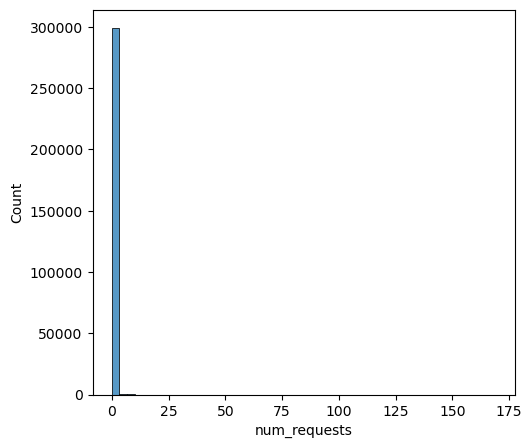

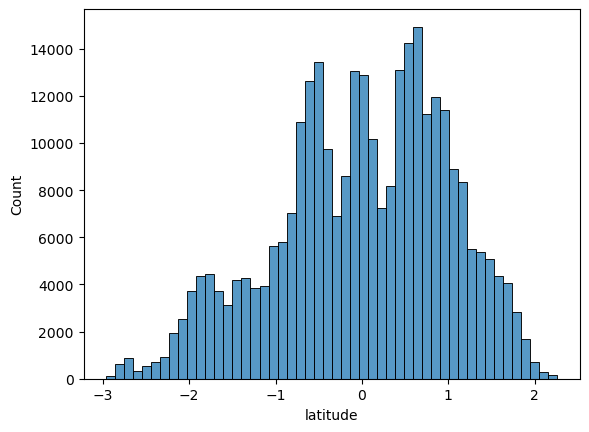

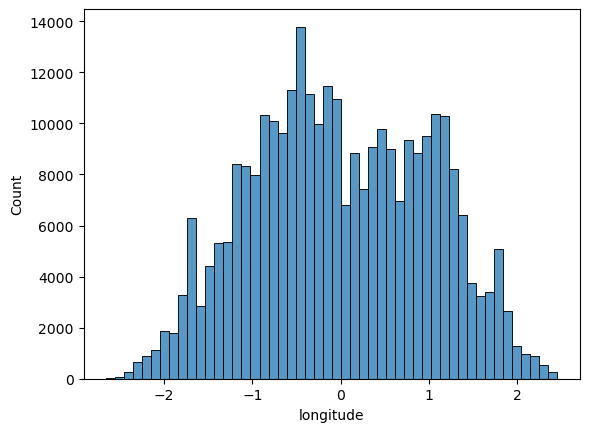

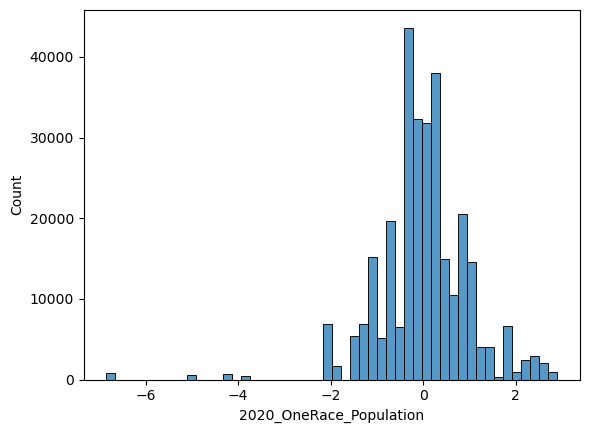

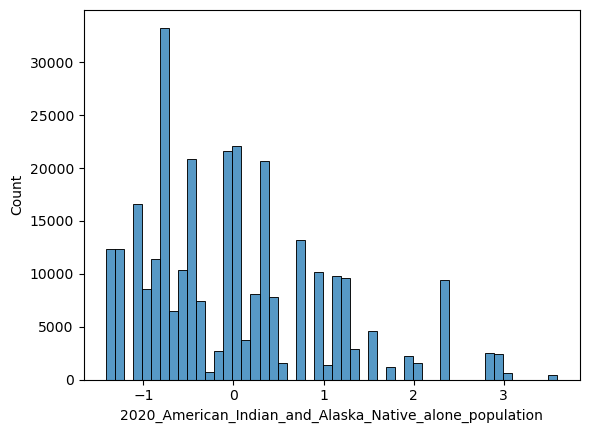

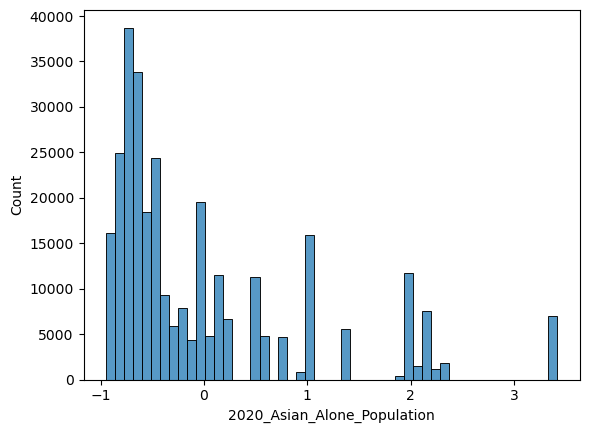

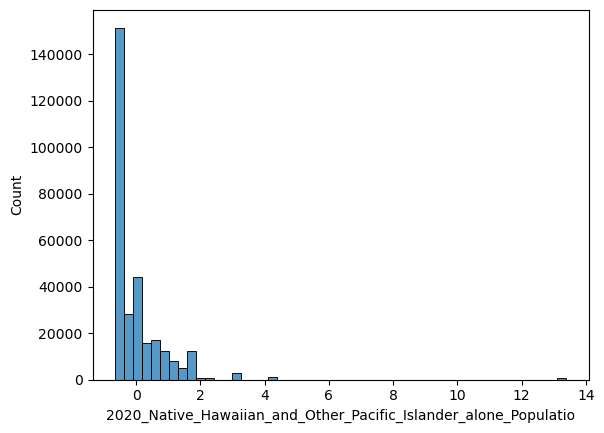

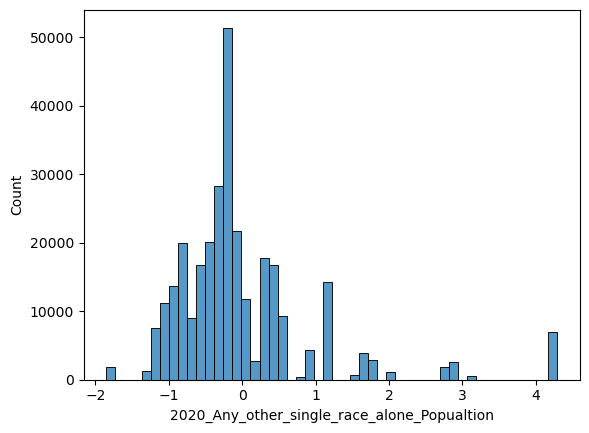

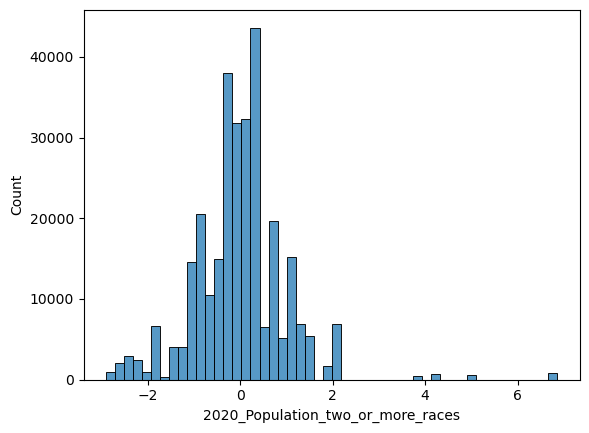

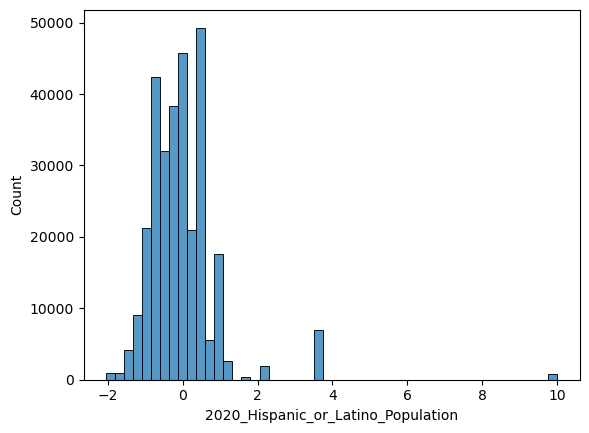

In [124]:
plt.figure(figsize=(12,5))
plt.subplot(121)
for i in list:
    sns.histplot(data[i], bins=50)
    plt.show()

In [139]:
data.columns

Index(['num_requests', 'create_date_et', 'last_action_et', 'closed_date_et',
       'council_district', 'ward', 'police_zone', 'latitude', 'longitude',
       '2020_Total_Population',
       ...
       'dept_simplified_Public Safety', 'dept_simplified_SPIN Scooters',
       'dept_simplified_Sargent Electric', 'dept_simplified_School Guards',
       'time_taken', 'create_hour', 'create_month', 'is_holiday',
       'head_time_taken', 'tail_time_taken'],
      dtype='object', length=307)

# Models
## 1. linear regression
### Model 1

In [125]:
from sklearn.model_selection import cross_validate, TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [151]:
class RollingWindowSplit:
    def __init__(self, n_splits=2, window_size=365*2, test_size=365):
        self.n_splits = n_splits
        self.window_size = window_size
        self.test_size = test_size
    
    def split(self, X):
        n_samples = len(X)
        for i in range(self.n_splits):
            train_start = i * self.test_size
            train_end = train_start + self.window_size
            test_end = train_end + self.test_size
            
            if test_end > n_samples:
                break
                
            yield (
                np.arange(train_start, train_end),
                np.arange(train_end, test_end)
            )

def cross_val_with_metrics(model, X, y, cv):
    fold_results = []
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
        # split the data
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # train model
        model.fit(X_train, y_train)
        
        # predict
        y_pred = model.predict(X_test)
        
        # calculte matrics
        metrics = {
            'R²': r2_score(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred)
        }
        fold_results.append(metrics)
    
    return pd.DataFrame(fold_results)

In [163]:
X = data.drop(columns=['time_taken','create_date_et','closed_date_et','last_action_et','head_time_taken'])
y = data['time_taken']

model = LinearRegression()
cv = RollingWindowSplit(n_splits=2, window_size=365*2, test_size=365)  

# cross validation
results_df = cross_val_with_metrics(model, X, y, cv)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [164]:
print("performance:")
print(results_df)
print("\nmean:")
print(results_df.mean().to_frame().T)


performance:
         R²      RMSE       MAE
0 -0.136734  1.718200  0.981975
1  0.076582  1.455127  0.857004

mean:
         R²      RMSE      MAE
0 -0.030076  1.586664  0.91949


In [165]:
final_model = LinearRegression()
final_model.fit(X, y)

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': final_model.coef_,
    'abs_coef': np.abs(final_model.coef_)
}).sort_values('abs_coef', ascending=False)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [166]:
print("\nrank:")
print(coef_df.tail())


rank:
                         feature  coefficient  abs_coef
51       neighborhood_Banksville     0.000349  0.000349
2                           ward     0.000329  0.000329
11   2020_Asian_Alone_Population    -0.000099  0.000099
6          2020_Total_Population     0.000005  0.000005
301              tail_time_taken     0.000000  0.000000


#### Delete non-important features

In [167]:
# Define a quantiles (as threshold) to cut the important features
quantiles = np.arange(0.1, 1.0, 0.05)  

results = []

for q in quantiles:
    # 1. filtrate features
    threshold = coef_df['abs_coef'].quantile(q)
    significant_features = coef_df[coef_df['abs_coef'] > threshold]['feature']
    X_filtered = X[significant_features]
    
    # 2. cross validation
    model = LinearRegression() 
    cv = RollingWindowSplit(n_splits=2, window_size=365*2, test_size=365)
    results_df = cross_val_with_metrics(model, X_filtered, y, cv)
    
    # 3. get the result
    results.append({
        'quantile': q,
        'num_features': len(significant_features),
        'mean_R2': results_df['R²'].mean(),
        'mean_RMSE': results_df['RMSE'].mean(),
        'mean_MAE': results_df['MAE'].mean()
    })

results_df = pd.DataFrame(results).sort_values('mean_R2', ascending=False)

# get the optimal number
best_q = results_df.iloc[0]['quantile']

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame wi

optimal: 0.55
optimal result:
    quantile  num_features   mean_R2  mean_RMSE  mean_MAE
9       0.55           136  0.129151   1.458580  0.734374
10      0.60           121  0.128565   1.458964  0.731153
8       0.50           151  0.122085   1.464815  0.716067


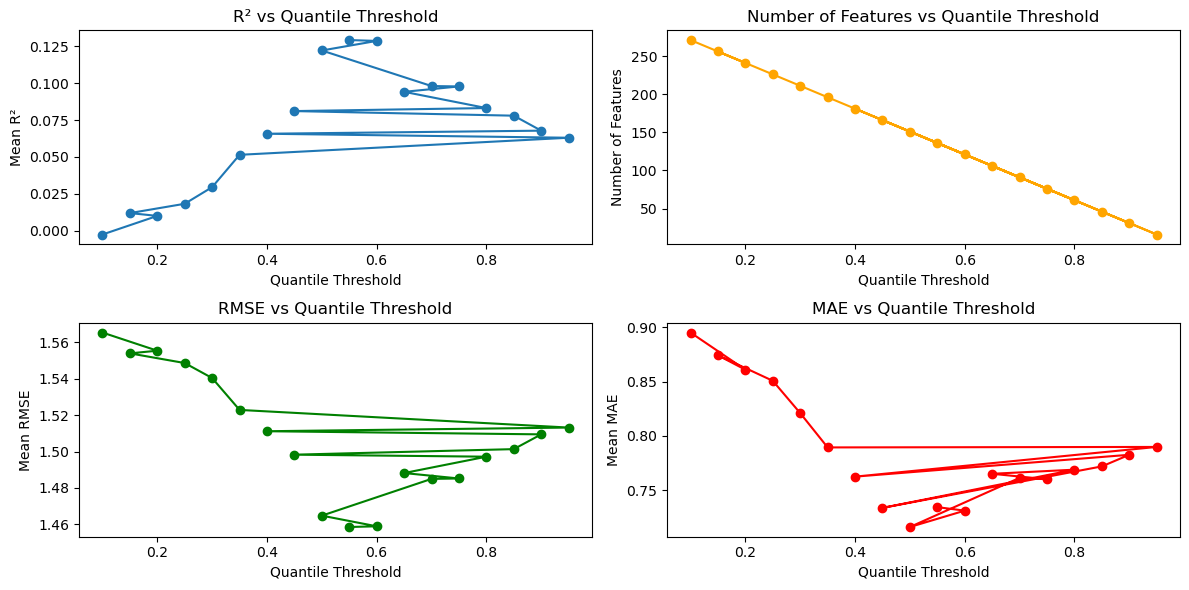

In [168]:
print(f"optimal: {best_q:.2f}")
print("optimal result:")
print(results_df.head(3))

# visualization check
plt.figure(figsize=(12, 6))

# R²
plt.subplot(2, 2, 1)
plt.plot(results_df['quantile'], results_df['mean_R2'], marker='o')
plt.title('R² vs Quantile Threshold')
plt.xlabel('Quantile Threshold')
plt.ylabel('Mean R²')

# # of features
plt.subplot(2, 2, 2)
plt.plot(results_df['quantile'], results_df['num_features'], marker='o', color='orange')
plt.title('Number of Features vs Quantile Threshold')
plt.xlabel('Quantile Threshold')
plt.ylabel('Number of Features')

# RMSE
plt.subplot(2, 2, 3)
plt.plot(results_df['quantile'], results_df['mean_RMSE'], marker='o', color='green')
plt.title('RMSE vs Quantile Threshold')
plt.xlabel('Quantile Threshold')
plt.ylabel('Mean RMSE')

# MAE
plt.subplot(2, 2, 4)
plt.plot(results_df['quantile'], results_df['mean_MAE'], marker='o', color='red')
plt.title('MAE vs Quantile Threshold')
plt.xlabel('Quantile Threshold')
plt.ylabel('Mean MAE')

plt.tight_layout()
plt.show()

In [169]:
threshold = coef_df['abs_coef'].quantile(0.55)
significant_features = coef_df[coef_df['abs_coef'] > threshold]['feature']

In [170]:
X_filtered = X[significant_features]

### Model 2
#### Use important features to train again (Baseline)

In [171]:
model = LinearRegression()
cv = RollingWindowSplit(n_splits=2, window_size=365*2, test_size=365)  

# cross validation
results_df = cross_val_with_metrics(model, X_filtered, y, cv)

In [172]:
print("performance:")
print(results_df)
print("\nmean:")
print(results_df.mean().to_frame().T)

performance:
         R²      RMSE       MAE
0  0.024406  1.591764  0.817168
1  0.233896  1.325396  0.651579

mean:
         R²     RMSE       MAE
0  0.129151  1.45858  0.734374


# 2. Lasson
### Model 3

In [173]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

def cross_val_lasso(X_data, y_data, cv):
    fold_results = []
    feature_counts = []
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_data)):
        X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
        y_train, y_test = y_data.iloc[train_idx], y_data.iloc[test_idx]
        
        # standardized (because it is sensitive)
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # choose alpha automatically
        lasso = LassoCV(
            alphas=np.logspace(-6, 3, 100),  
            cv=TimeSeriesSplit(n_splits=10),
            max_iter=10000,
            tol=1e-5,
            random_state=42
        )
        lasso.fit(X_train_scaled, y_train)
        
        y_pred = lasso.predict(X_test_scaled)
        
        metrics = {
            'R²': r2_score(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred),
            'num_features': np.sum(lasso.coef_ != 0)
        }
        fold_results.append(metrics)
    
    return pd.DataFrame(fold_results)

In [174]:
cv = RollingWindowSplit(n_splits=2, window_size=365*2, test_size=365)

In [175]:
results_full = cross_val_lasso(X, y, cv)
print("\nperformance:")
print(results_full)
print("\nmean:")
print(results_full.mean().to_frame().T)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1117: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  if np.may_share_memory(array, array_orig):
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:1117: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_val


performance:
         R²      RMSE       MAE  num_features
0 -0.007069  1.617238  0.858434             1
1 -0.001429  1.515346  0.791597             0

mean:
         R²      RMSE       MAE  num_features
0 -0.004249  1.566292  0.825016           0.5


E:\anaconda\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.2661057376753888, tolerance: 0.01484765637468837
  model = cd_fast.enet_coordinate_descent_gram(


### Model 4
#### Use the important features from regression

In [177]:
results_filtered = cross_val_lasso(X_filtered, y, cv)
print("\n performance:")
print(results_filtered)
print("\n mean:")
print(results_filtered.mean().to_frame().T)


 performance:
         R²      RMSE       MAE  num_features
0 -0.001527  1.612782  0.849625             2
1  0.234954  1.324480  0.648527            34

 mean:
         R²      RMSE       MAE  num_features
0  0.116714  1.468631  0.749076          18.0


# 3. Random Forest
### Model 5

In [180]:
from sklearn.ensemble import RandomForestRegressor

In [181]:
from sklearn.model_selection import GridSearchCV

class RollingWindowSplit2:
    def __init__(self, n_splits=2, window_size=365*2, test_size=365):
        self.n_splits = n_splits
        self.window_size = window_size
        self.test_size = test_size
        
    def split(self, X, y=None, groups=None):  
        n_samples = len(X)
        for i in range(self.n_splits):
            train_start = i * self.test_size
            train_end = train_start + self.window_size
            test_end = train_end + self.test_size
            
            if test_end > n_samples:
                break
                
            yield (
                np.arange(train_start, train_end),
                np.arange(train_end, test_end)
            )
    
    def get_n_splits(self, X=None, y=None, groups=None):  # correct the rolling window validation to match RF's requirements
        return self.n_splits

cv = RollingWindowSplit2(n_splits=2, window_size=365*2, test_size=365)

In [182]:
# Define GridSearchCV parameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt', 0.8]
}

In [183]:
for train_idx, test_idx in cv.split(X, y, groups=None):  
    print(f"train size: {len(train_idx)}, test size: {len(test_idx)}")

rf_tuned = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    verbose=2
)
rf_tuned.fit(X, y)

train size: 730, test size: 365
train size: 730, test size: 365
Fitting 2 folds for each of 24 candidates, totalling 48 fits


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.6s


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.6s


...

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=None, max_features=0.8, min_samples_split=10, n_estimators=200; total time=   5.5s


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=None, max_features=0.8, min_samples_split=10, n_estimators=200; total time=   5.9s


GridSearchCV(cv=<__main__.RollingWindowSplit2 object at 0x0000017D2FE44AA0>,
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 0.8],
                         'min_samples_split': [5, 10],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [184]:
print("optimal parameters:", rf_tuned.best_params_)

optimal parameters: {'max_depth': 10, 'max_features': 0.8, 'min_samples_split': 10, 'n_estimators': 200}


In [185]:
# use the optimal parameters to train and validate
best_model = rf_tuned.best_estimator_

cv = RollingWindowSplit2(n_splits=2, window_size=365*2, test_size=365)
results = cross_val_with_metrics(best_model, X, y, cv)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [186]:
print("performance:")
print(results)
print("\nmean:")
print(results.mean().to_frame().T)

performance:
         R²      RMSE       MAE
0 -0.005275  1.615797  0.741193
1  0.184554  1.367412  0.692387

mean:
        R²      RMSE      MAE
0  0.08964  1.491604  0.71679


#### check non-important features

In [187]:
importances = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importance.tail(40))

                                               feature  importance
173                   category_Crashes and Close Calls         0.0
174  category_Crosswalk and Street Markings, Mainte...         0.0
175                            category_Crosswalk, New         0.0
177                        category_Curb Painting, New         0.0
178                    category_Curb paint application         0.0
179                                category_DOMI Andon         0.0
180                                   category_Dashcam         0.0
181             category_Deer Management Pilot Program         0.0
182                               category_EMS Billing         0.0
183                       category_Early Trash Set Out         0.0
153       category_Board Up (City-owned property only)         0.0
150               category_Blocked or Closed Sidewalks         0.0
110                           neighborhood_Polish Hill         0.0
149               category_Bicycle/Pedestrian Concerns        

### Model 6
#### Use the important features from regression

In [188]:
rf_tuned2 = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    verbose=2
)
rf_tuned2.fit(X_filtered, y)

Fitting 2 folds for each of 24 candidates, totalling 48 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=200; total time=   0.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=200; total time=   0.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=10, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=10, n_estimators=100; total time=   0.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=10, n_estimators=200; total time=   0.7s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=10, n_estimators=200; total time=   0.6s
[CV] END max_depth=10, max_features=0.8, min_samples_split=5, n_estimators=100; total time=   0.4s
[CV] END max_depth=10, max_features=

GridSearchCV(cv=<__main__.RollingWindowSplit2 object at 0x0000017D2B357140>,
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 0.8],
                         'min_samples_split': [5, 10],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [189]:
best_model2 = rf_tuned2.best_estimator_

cv = RollingWindowSplit2(n_splits=2, window_size=365*2,  test_size=365)
results2 = cross_val_with_metrics(best_model2, X_filtered, y, cv)

print("performance:")
print(results2)
print("\nmean:")
print(results2.mean().to_frame().T)

performance:
         R²      RMSE       MAE
0  0.023330  1.592643  0.808583
1  0.223651  1.334229  0.658775

mean:
        R²      RMSE       MAE
0  0.12349  1.463436  0.733679


### Model 7
#### Set a threshold to check whether it can improve performance

In [ ]:
# like > 0.01
selected_features = feature_importance[feature_importance['importance'] > 0.01]['feature']
X_filtered_rf = X[selected_features]

In [ ]:
X_filtered_rf.shape

In [193]:
rf_tuned3 = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    verbose=2
)
rf_tuned3.fit(X_filtered_rf, y)

Fitting 2 folds for each of 24 candidates, totalling 48 fits


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.3s


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   0.3s


...

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=None, max_features=0.8, min_samples_split=10, n_estimators=200; total time=   2.1s


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


[CV] END max_depth=None, max_features=0.8, min_samples_split=10, n_estimators=200; total time=   2.4s


GridSearchCV(cv=<__main__.RollingWindowSplit2 object at 0x0000017D37BA3710>,
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 0.8],
                         'min_samples_split': [5, 10],
                         'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error', verbose=2)

In [194]:
best_model3 = rf_tuned3.best_estimator_

cv = RollingWindowSplit2(n_splits=2, window_size=365*2, test_size=365)
results3 = cross_val_with_metrics(best_model3, X_filtered_rf, y, cv)

print("performance:")
print(results3)
print("\nmean:")
print(results3.mean().to_frame().T)

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


performance:
        R²      RMSE       MAE
0  0.00393  1.608382  0.778023
1  0.20775  1.347823  0.715012

mean:
        R²      RMSE       MAE
0  0.10584  1.478102  0.746518


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


#### Use for loop to select threshold and parameters

In [195]:
threshold_options = {
    'method': 'quantile', 
    'values': [0.5, 0.6, 0.7, 0.8, 0.9]  #Select quantile
}

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [5, 10],
    'max_features': ['sqrt', 0.8]
}

results = []
best_config = {
    'threshold': None,
    'model': None,
    'features': None,
    'performance': None
}

for value in threshold_options['values']:
    # filter features
    if threshold_options['method'] == 'quantile':
        threshold = feature_importance['importance'].quantile(value)
        selected_features = feature_importance[feature_importance['importance'] > threshold]['feature']
    else:
        selected_features = feature_importance[feature_importance['importance'] > value]['feature']
    
    X_filtered = X[selected_features]
    
    if X_filtered.shape[1] == 0:
        print(f"skip {value}：no feature")
        continue
    
    # grid search to improve parameters
    rf_tuned = GridSearchCV(
        estimator=RandomForestRegressor(random_state=42),
        param_grid=param_grid,
        cv=RollingWindowSplit2(n_splits=2, window_size=365*2, test_size=365),
        scoring='neg_root_mean_squared_error',
        verbose=0,
        n_jobs=-1
    )
    rf_tuned.fit(X_filtered, y)
    
    # cross validation
    best_model = rf_tuned.best_estimator_
    cv_results = cross_val_with_metrics(best_model, X_filtered, y, 
                                       RollingWindowSplit2(n_splits=2, window_size=365*2, test_size=365))
    mean_metrics = cv_results.mean().to_dict()
    
    # result
    results.append({
        'threshold_value': value,
        'threshold_type': threshold_options['method'],
        'num_features': X_filtered.shape[1],
        **mean_metrics
    })
    
    # update the optimal configuration
    if best_config['performance'] is None or mean_metrics['R²'] > best_config['performance']['R²']:
        best_config.update({
            'threshold': value,
            'model': best_model,
            'features': X_filtered.columns.tolist(),
            'performance': mean_metrics
        })

# Get results
results_df = pd.DataFrame(results)
print("comparison:")
print(results_df.sort_values('R²', ascending=False))

print("\noptimal:")
print(f"method: {threshold_options['method']}")
print(f"value: {best_config['threshold']}")
print(f"# of features: {len(best_config['features'])}")
print(f"mean R²: {best_config['performance']['R²']:.3f}")
print(f"features remained: {best_config['features'][:5]}")

E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame wi

comparison:
   threshold_value threshold_type  num_features        R²      RMSE       MAE
4              0.9       quantile            31  0.094527  1.487391  0.753470
3              0.8       quantile            61  0.078026  1.501089  0.728747
0              0.5       quantile            97  0.074579  1.503627  0.733919
1              0.6       quantile            97  0.074579  1.503627  0.733919
2              0.7       quantile            91  0.068145  1.508905  0.732458

optimal:
method: quantile
value: 0.9
# of features: 31
mean R²: 0.095
features remained: ['category_Curb Paint, Maintenance', 'category_Garbage and Litter Issues', 'num_requests', '2020_OneRace_Population', '2020_Native_Hawaiian_and_Other_Pacific_Islander_alone_Populatio']


E:\anaconda\Lib\site-packages\sklearn\utils\validation.py:921: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


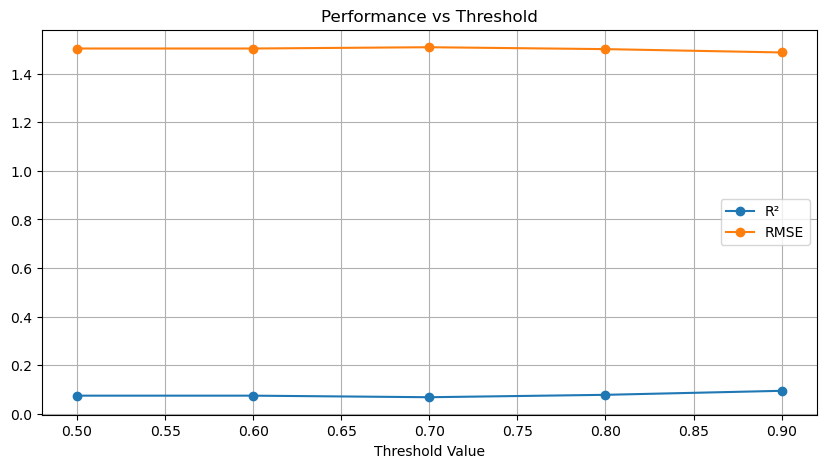

In [196]:
# Visualization to check its performance
plt.figure(figsize=(10,5))
plt.plot(results_df['threshold_value'], results_df['R²'], marker='o', label='R²')
plt.plot(results_df['threshold_value'], results_df['RMSE'], marker='o', label='RMSE')
plt.xlabel('Threshold Value')
plt.title('Performance vs Threshold')
plt.legend()
plt.grid(True)
plt.show()

# 1. XGBoost
### Model 8

In [197]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

def xgb_cross_val(X, y, cv, param_grid=None):
    fold_results = []
    feature_importances = []
    
    # default parameters
    default_params = {
        'n_estimators': 100,
        'max_depth': 6,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'random_state': 42
    }
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # initial model (grid search)
        if param_grid:
            model = GridSearchCV(
                XGBRegressor(**default_params),
                param_grid,
                cv=3,
                scoring='neg_mean_squared_error'
            )
            model.fit(X_train, y_train)
            best_model = model.best_estimator_
        else:
            best_model = XGBRegressor(**default_params).fit(X_train, y_train)
        
        # predict
        y_pred = best_model.predict(X_test)
        fold_results.append({
            'R²': r2_score(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'MAE': mean_absolute_error(y_test, y_pred)
        })
        
        # get feature importance
        importances = best_model.feature_importances_
        feature_importances.append(pd.Series(importances, index=X.columns))
    
    importance_df = pd.concat(feature_importances, axis=1).mean(axis=1)
    return pd.DataFrame(fold_results), importance_df

In [198]:
cv = RollingWindowSplit2(n_splits=2, window_size=365*2, test_size=365)

# parameters for grid search
param_grid = {
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8]
}

# cross validation to imporve parameters
results_df, importance_df = xgb_cross_val(X, y, cv, param_grid)

E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: S

In [199]:
print("performance:")
print(results_df)
print("\nmean:")
print(results_df.mean().to_frame().T)

performance:
         R²      RMSE       MAE
0 -0.032052  1.637175  0.771484
1  0.156819  1.390472  0.685000

mean:
         R²      RMSE       MAE
0  0.062384  1.513823  0.728242


#### Check the non-important features

In [200]:
importance_df.sort_values().head(40)

category_Blocked or Closed Sidewalks                   0.0
category_Crosswalk, New                                0.0
category_Curb Painting, New                            0.0
category_Curb paint application                        0.0
category_DOMI Andon                                    0.0
category_Dashcam                                       0.0
category_Deer Management Pilot Program                 0.0
category_EMS Billing                                   0.0
category_Early Trash Set Out                           0.0
category_Fire Safety System Not Working                0.0
category_Flooding                                      0.0
category_Food Safety Complaints                        0.0
category_Graffiti in Right of Way                      0.0
category_Grate, Stormwater                             0.0
category_Crosswalk and Street Markings, Maintenance    0.0
category_Greenways                                     0.0
category_Handicap Parking Signs, Removal               0

### Model 9
#### Use the important features from the regression

In [201]:
results_df2, importance_df2 = xgb_cross_val(X_filtered, y, cv, param_grid)

E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
E:\anaconda\Lib\site-packages\xgboost\data.py:399: UserWarning: S

In [202]:
print("performance:")
print(results_df2)
print("\nmean:")
print(results_df2.mean().to_frame().T)

performance:
         R²      RMSE       MAE
0 -0.027146  1.633279  0.740659
1  0.165533  1.383268  0.716843

mean:
         R²      RMSE       MAE
0  0.069193  1.508274  0.728751


### Model 10

In [ ]:
from sklearn.feature_selection import SelectFromModel

threshold_options = {
    'method': 'quantile', 
    'values': [0.5, 0.6, 0.7, 0.8, 0.9]  # quantile
}

xgb_param_grid = {
    'max_depth': [5, 7, 9],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8]
}


results = []
best_config = {
    'threshold': None,
    'model': None,
    'features': None,
    'performance': None
}

# get global importance
base_model = XGBRegressor(n_estimators=100, random_state=42)
base_model.fit(X, y)
global_importance = pd.Series(base_model.feature_importances_, index=X.columns)

for value in threshold_options['values']:
    # filter features
    if threshold_options['method'] == 'quantile':
        threshold = global_importance.quantile(value)
    else:
        threshold = value

    selector = SelectFromModel(base_model, threshold=threshold, prefit=True)
    X_filtered = pd.DataFrame(selector.transform(X), columns=X.columns[selector.get_support()])
    
    if X_filtered.shape[1] == 0:
        print(f"skip {value}: no feature selected")
        continue
    
    # gird search for parameters improvement
    xgb = XGBRegressor(n_estimators=1000, random_state=42)
    grid_search = GridSearchCV(
        xgb,
        xgb_param_grid,
        cv=RollingWindowSplit2(n_splits=2, window_size=365*2, test_size=365),
        scoring='neg_root_mean_squared_error',
        verbose=0,
        n_jobs=-1
    )
    grid_search.fit(X_filtered, y)
    
    # cross validation
    best_model = grid_search.best_estimator_
    cv_results = cross_val_with_metrics(best_model, X_filtered, y, 
                                      RollingWindowSplit2(n_splits=2, window_size=365*2, test_size=365))
    mean_metrics = cv_results.mean().to_dict()
    
    # result
    results.append({
        'threshold_value': value,
        'threshold_type': threshold_options['method'],
        'num_features': X_filtered.shape[1],
        **mean_metrics
    })
    
    # update the optimal configuration
    if best_config['performance'] is None or mean_metrics['R²'] > best_config['performance']['R²']:
        best_config.update({
            'threshold': value,
            'model': best_model,
            'features': X_filtered.columns.tolist(),
            'performance': mean_metrics
        })

In [204]:
results_df = pd.DataFrame(results)
print("comparison:")
print(results_df.sort_values('R²', ascending=False))

print("\noptimal:")
print(f"method: {threshold_options['method']}")
print(f"threshold: {best_config['threshold']}")
print(f"# of features: {len(best_config['features'])}")
print(f"mean R²: {best_config['performance']['R²']:.3f}")
print(f"importance features examples: {best_config['features'][:5]}")

comparison:
   threshold_value threshold_type  num_features        R²      RMSE       MAE
3              0.8       quantile            61 -0.017495  1.576460  0.769949
2              0.7       quantile            91 -0.046290  1.598846  0.786921
4              0.9       quantile            31 -0.055281  1.603805  0.757120
0              0.5       quantile           151 -0.055281  1.605732  0.787950
1              0.6       quantile           121 -0.058993  1.608745  0.776273

optimal:
method: quantile
threshold: 0.8
# of features: 61
mean R²: -0.017
importance features examples: ['num_requests', 'ward', 'police_zone', 'longitude', '2020_Total_Population']
